In [49]:
#Nandhini.N

In [50]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [51]:
(X_train_full,y_train_full),(X_test,y_test)=keras.datasets.mnist.load_data()
X_train = X_train / 255.0
X_test = X_test / 255.0
print(X_train.shape)
print(y_train.shape)

(45000, 28, 28)
(45000,)


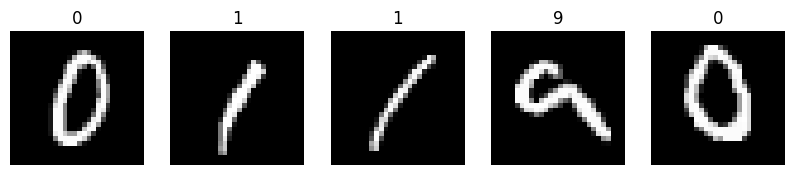

In [52]:
plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.show()

In [53]:
model = tf.keras.Sequential()

In [54]:
model.add(tf.keras.layers.Flatten(input_shape=(28,28)))
model.add(tf.keras.layers.Dense(128, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [55]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [56]:
history = model.fit(
    X_train,
    y_train,
    epochs=3
)

Epoch 1/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.1124 - loss: 2.3016
Epoch 2/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.1132 - loss: 2.3013
Epoch 3/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.1132 - loss: 2.3013


In [57]:
loss,accuracy=model.evaluate(X_test,y_test)
print("Accuracy:",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1144 - loss: 2.4455
Accuracy: 0.1143999993801117


In [58]:
y_pred = model.predict(X_test)

pred = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


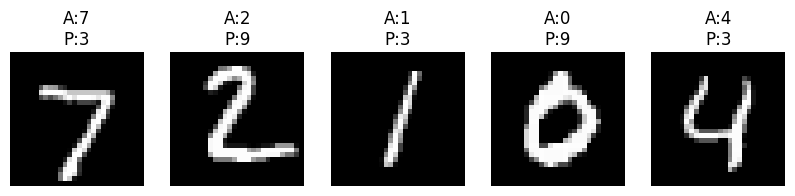

In [59]:
plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title("A:"+str(y_test[i])+"\nP:"+str(pred[i]))
    plt.axis("off")

plt.show()


Wrong Predictions: 8856


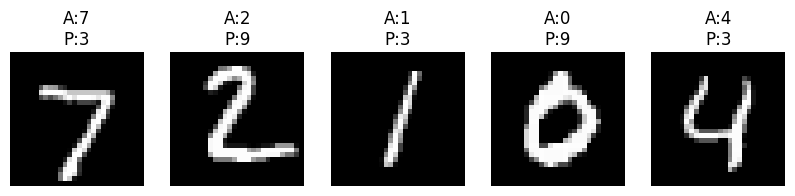

In [60]:
wrong = np.where(pred != y_test)[0]

print("Wrong Predictions:", len(wrong))

plt.figure(figsize=(10,2))

for i in range(5):
    j = wrong[i]
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[j], cmap="gray")
    plt.title("A:"+str(y_test[j])+"\nP:"+str(pred[j]))
    plt.axis("off")

plt.show()